# Project: Investigate a Dataset - IMDB Movie Database
## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

This project uses the TMDB Movies dataset (tmdb-movies.csv). Each row represents a movie, with columns describing release timing, popularity/ratings, cast/genre metadata, and and possibly budget and revenue. The dataset size is 10,866 movies and 21 columns. 

#### Column Descriptions

<li>id: TMDB internal movie ID</li>
<li>imdb_id: IMDb identifier for the movie</li>
<li>popularity: A TMDB popularity score, out of 5 stars</li>
<li>budget: Movie budget in nominal dollars</li>
<li>revenue: Movie revenue in nominal dollars</li>
<li>original_title: Movie title as originally released</li>
<li>cast: Main cast list</li>
<li>homepage: URL for the movie’s homepage</li>
<li>director: Director name</li>
<li>tagline: Marketing tagline</li>
<li>keywords: Keyword tags</li>
<li>overview: Short plot summary</li>
<li>runtime: Runtime in minutes</li>
<li>genres: Genres</li>
<li>production_companies: Company names</li>
<li>release_date: Release date</li>
<li>vote_count: Number of votes received on TMDB</li>
<li>vote_average: Average TMDB rating (typically 0–10).</li>
<li>release_year: Release year</li>
<li>budget_adj: Budget adjusted for inflation/li>
<li>revenue_adj: Revenue adjusted for inflation</li>


### Question(s) for Analysis
 
The main question we will be looking at is "Once we account for budget, are popularity and ratings still assocaited with adjusted revenue?" (I'm looking at you Avatar...)

In [1]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.2f}'.format

# --- Global purple theme for the notebook - digging this out of the dustbin ---
PURPLE = "#6A0DAD"        # main purple
PURPLE_LIGHT = "#C7A3E6"  # light purple fill
GRID = "#E6D9F2"          # very light purple grid

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": PURPLE,
    "axes.labelcolor": PURPLE,
    "axes.titlecolor": PURPLE,
    "xtick.color": PURPLE,
    "ytick.color": PURPLE,
    "grid.color": GRID,
    "grid.linestyle": "-",
    "grid.linewidth": 0.8,
    "axes.grid": True,
    "axes.axisbelow": True,
    "font.size": 11,
})

<a id='wrangling'></a>
## Data Wrangling

Loading the movie dataset. Creating a intial copy and a working copy.

In [2]:
movie_db_intial = pd.read_csv('Database_TMDb_movie_data/tmdb-movies.csv')
movie_db_working = movie_db_intial.copy()

Taking a look at data set.

In [3]:
movie_db_intial.shape

(10866, 21)

In [4]:
movie_db_intial.columns

Index(['id', 'imdb_id', 'popularity', 'budget', 'revenue', 'original_title',
       'cast', 'homepage', 'director', 'tagline', 'keywords', 'overview',
       'runtime', 'genres', 'production_companies', 'release_date',
       'vote_count', 'vote_average', 'release_year', 'budget_adj',
       'revenue_adj'],
      dtype='object')

In [5]:
movie_db_intial.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.99,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.50,2015,137999939.28,1392445892.52
1,76341,tt1392190,28.42,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.10,2015,137999939.28,348161292.49
2,262500,tt2908446,13.11,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.30,2015,101199955.47,271619025.41
3,140607,tt2488496,11.17,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.50,2015,183999919.04,1902723129.80
4,168259,tt2820852,9.34,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.30,2015,174799923.09,1385748801.47


In [6]:
movie_db_intial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

Have some missing data for sure.

In [7]:
movie_db_intial.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.00,10866.00,10866.00,10866.00,10866.00,10866.00,10866.00,10866.00,10866.00,10866.00
mean,66064.18,0.65,14625701.09,39823319.79,102.07,217.39,5.97,2001.32,17551039.82,51364363.25
std,92130.14,1.00,30913213.83,117003486.58,31.38,575.62,0.94,12.81,34306155.72,144632485.04
min,5.00,0.00,0.00,0.00,0.00,10.00,1.50,1960.00,0.00,0.00
25%,10596.25,0.21,0.00,0.00,90.00,17.00,5.40,1995.00,0.00,0.00
50%,20669.00,0.38,0.00,0.00,99.00,38.00,6.00,2006.00,0.00,0.00
75%,75610.00,0.71,15000000.00,24000000.00,111.00,145.75,6.60,2011.00,20853251.08,33697095.72
max,417859.00,32.99,425000000.00,2781505847.00,900.00,9767.00,9.20,2015.00,425000000.00,2827123750.41


There are 0's in the data set we need to get rid off.

Lets check for duplicates in both forms of IDs.

In [8]:
movie_db_intial.duplicated().sum()

1

In [9]:
movie_db_intial['imdb_id'].duplicated().sum(), movie_db_intial['id'].duplicated().sum()  

(10, 1)

Some duplication.


### Data Cleaning
 

Making a copy of our initial database. Just in case.

In [10]:
movie_db_working = movie_db_intial.copy()

Since we'll be replacing a lot of zeros with NaN throughout this project, we'll build a reusable function to handle that cleanly.

In [11]:
def zero_to_nan(df, cols):
    df = df.copy()
    for i in cols:
        df.loc[df[i] == 0, i] = np.nan
    return df

Dropping the duplicate ids in the dataset.

In [12]:
movie_db_working = movie_db_working.drop_duplicates(subset=['id', 'imdb_id']).reset_index(drop=True)

Lets double check for duplicates again.

In [13]:
movie_db_working.duplicated().sum()

0

Lets clean up the release date so it's easier to read, by at least me, the coerce flag will put NaT for ones that error out.

In [14]:
movie_db_working['release_date'] = pd.to_datetime(movie_db_working['release_date'], errors='coerce')

Replacing 0's with NaN's. This is going to reduce our workable dataset size, but we need to remove the effect of the unknowns.

In [15]:
movie_db_working = zero_to_nan(movie_db_working, ['budget_adj', 'revenue_adj'])
movie_db_working = zero_to_nan(movie_db_working, ['budget', 'revenue'])

Going to use the log function to reduce the skew in the budget/revenue columns. Smaller numbers will be easier to deal with.

In [16]:
movie_db_working['log_budget_adj'] = np.log10(movie_db_working['budget_adj'])
movie_db_working['log_revenue_adj'] = np.log10(movie_db_working['revenue_adj'])

Going to derive adjust profit and also calculate the adjusted return of investment. May use these later, or not. Handy to have on hand anyway.

In [17]:
movie_db_working['profit_adj'] = movie_db_working['revenue_adj'] - movie_db_working['budget_adj']
movie_db_working['roi_adj'] = movie_db_working['revenue_adj'] / movie_db_working['budget_adj']

Let's see how the describe looks with the NaNs inputted.

In [18]:
movie_db_working.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj,log_budget_adj,log_revenue_adj,profit_adj,roi_adj
count,10865.00,10865.00,5169.00,4849.00,10865.00,10865.00,10865.00,10865.00,5169.00,4849.00,5169.00,4849.00,3854.00,3854.00
mean,66066.37,0.65,30739575.95,89238858.71,102.07,217.40,5.98,2001.32,36889069.20,115100887.63,7.18,7.39,92824697.22,298.04
std,92134.09,1.00,38904413.82,162080146.41,31.38,575.64,0.94,12.81,41960957.85,198855667.98,0.90,1.17,194071459.74,16442.56
min,5.00,0.00,1.00,2.00,0.00,10.00,1.50,1960.00,0.92,2.37,-0.04,0.37,-413912431.00,0.00
25%,10596.00,0.21,6000000.00,7732325.00,90.00,17.00,5.40,1995.00,8102293.07,10465848.09,6.91,7.02,-1504994.63,0.88
50%,20662.00,0.38,17000000.00,31853080.00,99.00,38.00,6.00,2006.00,22715052.32,43956661.16,7.36,7.64,27370641.16,2.12
75%,75612.00,0.71,40000000.00,99965753.00,111.00,146.00,6.60,2011.00,50083840.35,131648235.91,7.70,8.12,107454751.41,4.21
max,417859.00,32.99,425000000.00,2781505847.00,900.00,9767.00,9.20,2015.00,425000000.00,2827123750.41,8.63,9.45,2750136650.92,1018619.28


<a id='eda'></a>
## Exploratory Data Analysis


### Research Question 1 - Popularity and Revenue

#### Is Popularity Still Linked to Revenue When Budget Is Taken Into Account?

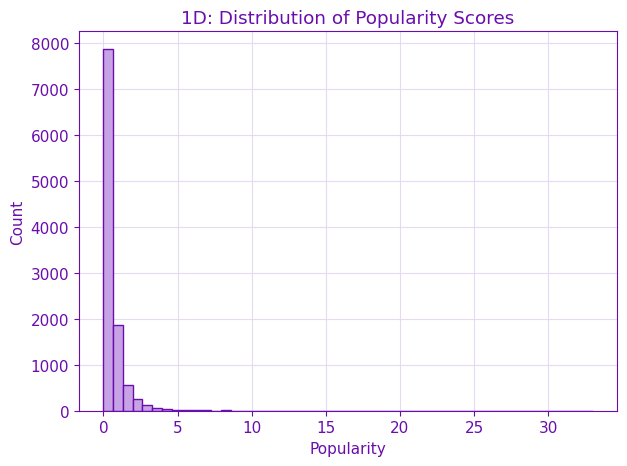

Popularity summary stats:
count   10865.00
mean        0.65
std         1.00
min         0.00
25%         0.21
50%         0.38
75%         0.71
max        32.99
Name: popularity, dtype: float64


In [19]:
# --- 1D: Distribution of Popularity ---
ax = movie_db_working['popularity'].dropna().plot(
    kind='hist', bins=50, color=PURPLE_LIGHT, edgecolor=PURPLE,
    title='1D: Distribution of Popularity Scores'
)
ax.set_xlabel('Popularity')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print("Popularity summary stats:")
print(movie_db_working['popularity'].describe())

Most movies have a popularity score below 2. A small number of blockbusters push the average up. The distribution is heavily skewed to the right. I'm looking at you Jurrasic Park...

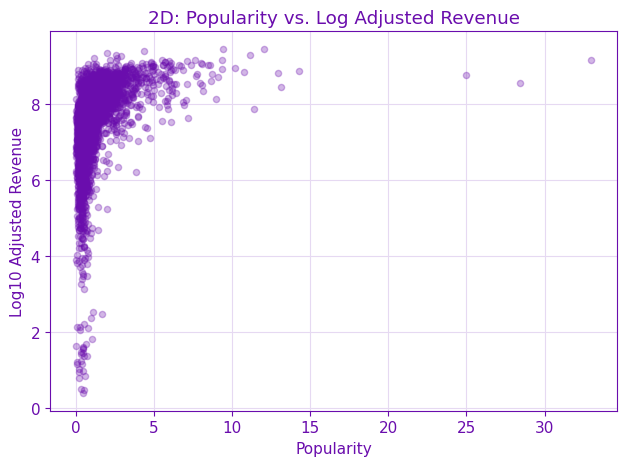

Correlation (popularity vs log_revenue_adj): 0.352


In [20]:
# --- 2D: Scatter plot of popularity vs. log_revenue_adj ---
eda_df = movie_db_working[['popularity', 'log_revenue_adj', 'log_budget_adj']].dropna()

ax = eda_df.plot(
    kind='scatter', x='popularity', y='log_revenue_adj',
    alpha=0.3, color=PURPLE, title='2D: Popularity vs. Log Adjusted Revenue'
)
ax.set_xlabel('Popularity')
ax.set_ylabel('Log10 Adjusted Revenue')
plt.tight_layout()
plt.show()

print("Correlation (popularity vs log_revenue_adj):", 
      eda_df['popularity'].corr(eda_df['log_revenue_adj']).round(3))

More popular films tend to earn more, but the relationship is noisy. Many low-popularity films still made good money. This is an association, not a cause.

In [21]:
# --- Controlling for budget: bin budget into quartiles and compare ---
eda_df = eda_df.copy()
eda_df['budget_quartile'] = pd.qcut(eda_df['log_budget_adj'], q=4,
                                     labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

for label, group in eda_df.groupby('budget_quartile', observed=True):
    corr = group['popularity'].corr(group['log_revenue_adj'])
    print(f"Budget quartile '{label}': popularity-revenue corr = {corr:.3f}")



Budget quartile 'Low': popularity-revenue corr = 0.283
Budget quartile 'Mid-Low': popularity-revenue corr = 0.276
Budget quartile 'Mid-High': popularity-revenue corr = 0.389
Budget quartile 'High': popularity-revenue corr = 0.387


Popularity still connects to revenue within each budget group. The link is weaker for low-budget films but holds across the board.

### Research Question 2  - Ratings and Revenue

#### Do Higher Ratings Mean Higher Revenue, Even After Accounting for Budget?

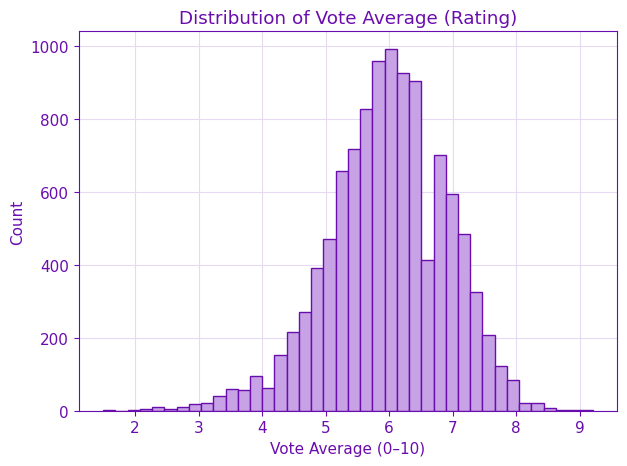

Vote average summary stats:
count   10865.00
mean        5.98
std         0.94
min         1.50
25%         5.40
50%         6.00
75%         6.60
max         9.20
Name: vote_average, dtype: float64


In [22]:
# --- 1D: Rating Distribution ---
ax = movie_db_working['vote_average'].dropna().plot(
    kind='hist', bins=40, color=PURPLE_LIGHT, edgecolor=PURPLE,
    title='Distribution of Vote Average (Rating)'
)
ax.set_xlabel('Vote Average (0–10)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print("Vote average summary stats:")
print(movie_db_working['vote_average'].describe())


Ratings are fairly evenly spread, centered around 6.0. Most films fall between 5 and 7.5. There are few extreme outliers.

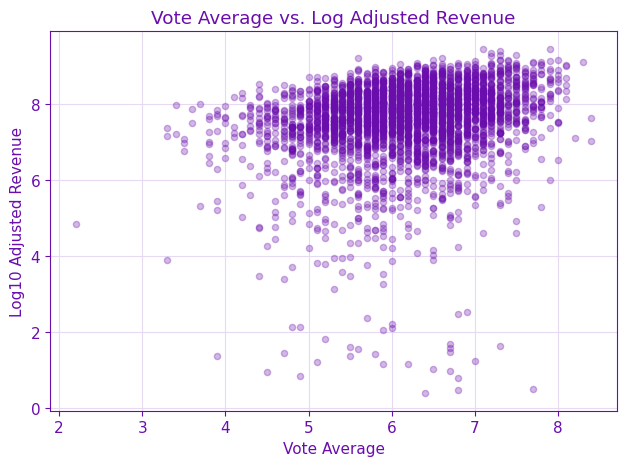

Correlation: 0.216


In [23]:
# --- 2D: Rating vs. Adjusted Revenue ---
eda_df2 = movie_db_working[['vote_average', 'log_revenue_adj', 'log_budget_adj']].dropna()

ax = eda_df2.plot(
    kind='scatter', x='vote_average', y='log_revenue_adj',
    alpha=0.3, color=PURPLE, title='Vote Average vs. Log Adjusted Revenue'
)
ax.set_xlabel('Vote Average')
ax.set_ylabel('Log10 Adjusted Revenue')
plt.tight_layout()
plt.show()

print("Correlation:", eda_df2['vote_average'].corr(eda_df2['log_revenue_adj']).round(3))


The link between ratings and revenue is weak. Some of the highest-earning films have average ratings. Highly rated films often earn less than expected. Ratings alone don't predict box office performance well.

Budget level 'Low': correlation = 0.221
Budget level 'Mid-Low': correlation = 0.294
Budget level 'Mid-High': correlation = 0.277
Budget level 'High': correlation = 0.421


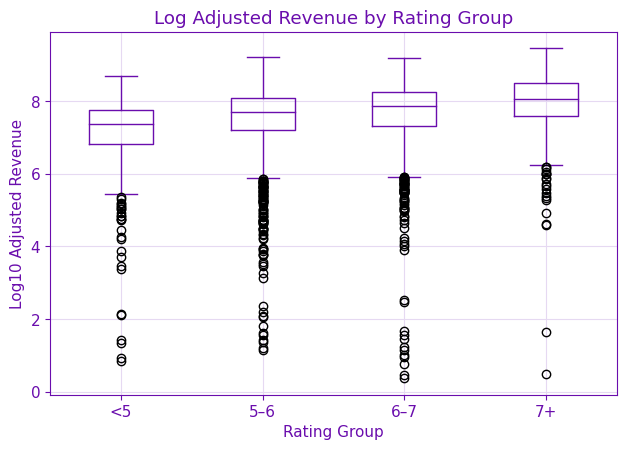

In [24]:
# --- Split by budget level ---
eda_df2 = eda_df2.copy()
eda_df2['budget_quartile'] = pd.qcut(eda_df2['log_budget_adj'], q=4,
                                      labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

for label, group in eda_df2.groupby('budget_quartile', observed=True):
    corr = group['vote_average'].corr(group['log_revenue_adj'])
    print(f"Budget level '{label}': correlation = {corr:.3f}")

# --- Box plots by rating group ---
eda_df2['rating_tier'] = pd.cut(eda_df2['vote_average'], bins=[0, 5, 6, 7, 10],
                                 labels=['<5', '5–6', '6–7', '7+'])
eda_df2.boxplot(column='log_revenue_adj', by='rating_tier', color=PURPLE, grid=True)
plt.suptitle('')
plt.title('Log Adjusted Revenue by Rating Group')
plt.xlabel('Rating Group')
plt.ylabel('Log10 Adjusted Revenue')
plt.tight_layout()
plt.show()


Higher-rated films earn slightly more on average, but the groups overlap a lot. Within each budget level, the rating-revenue link stays weak. Ratings don't add much once budget is factored in.

<a id='conclusions'></a>
## Conclusions

This analysis looked at one main question: once budget is accounted for, do popularity and ratings still connect to adjusted revenue?

What we found:

Popularity has a moderate positive link to adjusted revenue across all budget levels. More popular films tend to earn more, even when compared to films with similar budgets. That said, the relationship is noisy and driven partly by a few high-profile outliers.

Ratings show only a weak link to revenue. Some of the top-earning films have average ratings, while highly rated films often underperform at the box office. This pattern holds across all budget levels.

Overall, popularity is a better indicator of revenue than ratings — but neither variable is a strong predictor once budget is taken into account.

Limitations:

Missing data: More than half the dataset had no budget or revenue values. Films with complete data likely skew toward larger productions, so results may not apply to smaller or independent films.

No statistical testing: This is exploratory analysis only. No regression or significance testing was done, so we can't make formal claims about these relationships.

Other factors not considered: Genre, release year, franchise status, and marketing spend all likely affect both popularity and revenue. These were not controlled for.

Note: The patterns found here do not mean that popularity causes higher revenue. Many factors influence both at the same time.



## Areas for additional Research

Genre & Cast Effects

The dataset also includes genres and cast columns that weren't central to the main research question. These could be worth exploring in future work to see if they play a role in predicting revenue.

In [25]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 638850 bytes to Investigate_a_Dataset.html
